# Feature Engineering

## Objective

The objective of this notebook is to extract handcrafted image features that can distinguish genuine photographs from screen recapture images.

Instead of directly training deep learning models, several computer vision descriptors are computed to capture texture, color, frequency, edge, and reflection characteristics.

These engineered features are later used to train classical machine learning models such as Random Forest and XGBoost.

## Import Required Libraries

Import all libraries required for image processing, feature extraction, numerical computation, and data manipulation.

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

def extract_basic_features(image_path):

    img = cv2.imread(image_path)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape

    # Brightness
    brightness = np.mean(gray)

    # Contrast
    contrast = np.std(gray)

    # Laplacian Variance (Sharpness)
    lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    # Canny Edge Density
    edges = cv2.Canny(gray, 100, 200)

    edge_density = np.sum(edges > 0) / (h * w)

    return {
        "width": w,
        "height": h,
        "brightness": brightness,
        "contrast": contrast,
        "laplacian": lap_var,
        "edge_density": edge_density
    }

## Define Dataset Paths

Specify the directory paths for the real photograph and screen recapture image datasets.

In [3]:
REAL_DIR = "../dataset/real"
SCREEN_DIR = "../dataset/screen"

## Load Image File Paths

Collect all valid image filenames from both classes while filtering supported image formats.

In [4]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

real_images = [
    f for f in os.listdir(REAL_DIR)
    if f.lower().endswith(IMAGE_EXTENSIONS)
]

screen_images = [
    f for f in os.listdir(SCREEN_DIR)
    if f.lower().endswith(IMAGE_EXTENSIONS)
]

print(f"Real Images   : {len(real_images)}")
print(f"Screen Images : {len(screen_images)}")

Real Images   : 51
Screen Images : 51


## Extract Basic Image Statistics

Iterate through every image and compute simple descriptive statistics that provide an initial understanding of both image classes.

In [ ]:
records = []

for folder, label in [
    (REAL_DIR, "real"),
    (SCREEN_DIR, "screen")
]:

    for file in os.listdir(folder):

        if not file.lower().endswith(IMAGE_EXTENSIONS):
            continue

        path = os.path.join(folder, file)

        features = extract_basic_features(path)

        features["label"] = label
        features["filename"] = file

        records.append(features)

df = pd.DataFrame(records)

df.head()

,width,height,brightness,contrast,laplacian,edge_density,label,filename
0,1280,720,86.843356,72.940512,133.974220,0.028845,real,image_33.jpeg
1,899,1599,121.585207,53.212329,105.850217,0.020094,real,image_25.jpeg
2,1200,1600,115.583521,63.082602,113.837940,0.015818,real,image_48.jpeg
3,725,1600,128.303312,53.400933,724.985416,0.142362,real,image_6.jpeg
4,720,1600,127.736346,54.394504,1334.930272,0.091699,real,image_29.jpeg


## Compare Class-wise Statistics

Calculate the average feature values for both classes to identify potential differences between genuine photographs and screen recapture images.

In [6]:
df.groupby("label").mean(numeric_only=True)

,width,height,brightness,contrast,laplacian,edge_density
label,,,,,,
real,1343.176471,1518.529412,114.725747,57.909669,452.338215,0.057916
screen,1019.980392,1302.039216,103.498309,71.408821,234.347236,0.048768


## Frequency Domain Visualization

Visualize the Fourier Transform of sample images.

Screen recaptures often exhibit repetitive frequency patterns caused by display pixels and moiré artifacts that become visible in the frequency domain.

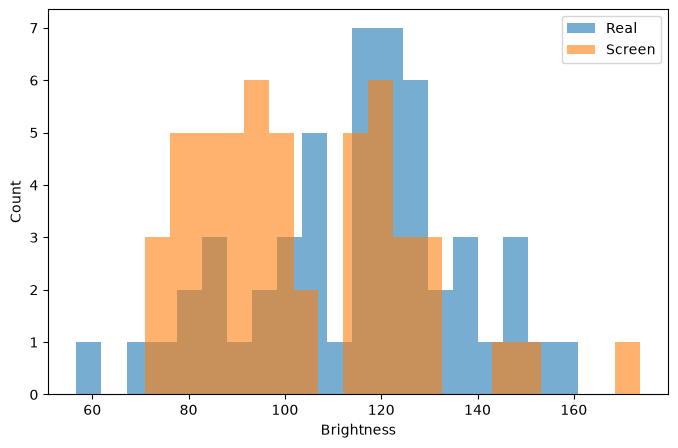

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    df[df.label=="real"]["brightness"],
    bins=20,
    alpha=0.6,
    label="Real"
)

plt.hist(
    df[df.label=="screen"]["brightness"],
    bins=20,
    alpha=0.6,
    label="Screen"
)

plt.xlabel("Brightness")
plt.ylabel("Count")
plt.legend()
plt.show()

## Fourier Transform Function

Define a reusable function for computing and visualizing the Fast Fourier Transform (FFT) of an image.

In [ ]:
def show_fft(image_path):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # FFT
    fft = np.fft.fft2(img)

    fft_shift = np.fft.fftshift(fft)

    magnitude = np.log(np.abs(fft_shift) + 1)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(magnitude, cmap="gray")
    plt.title("FFT Magnitude Spectrum")
    plt.axis("off")

    plt.show()

## FFT Example: Image Pair 1

Compare the frequency spectrum of one genuine photograph with one screen recapture image.

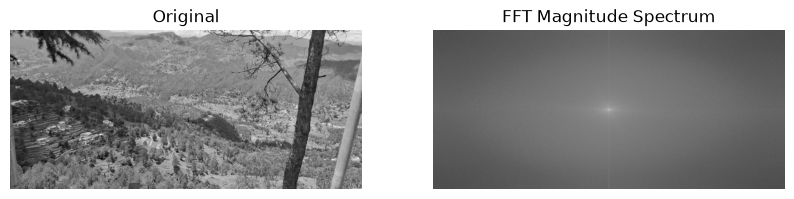

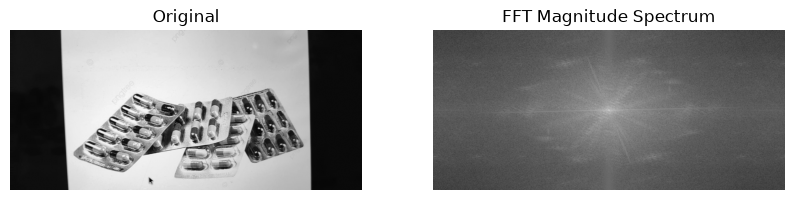

In [12]:
show_fft("../dataset/real/image_1.jpeg")
show_fft("../dataset/screen/image_1.jpeg")

## FFT Example: Image Pair 2

Repeat the frequency-domain comparison using another pair of images to observe consistent patterns.

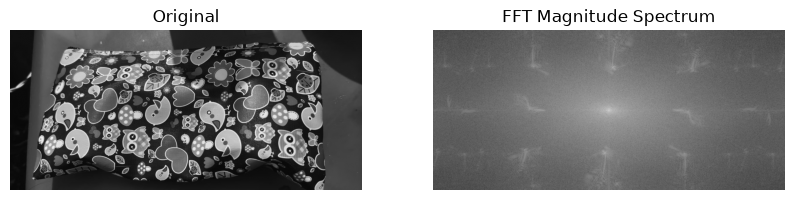

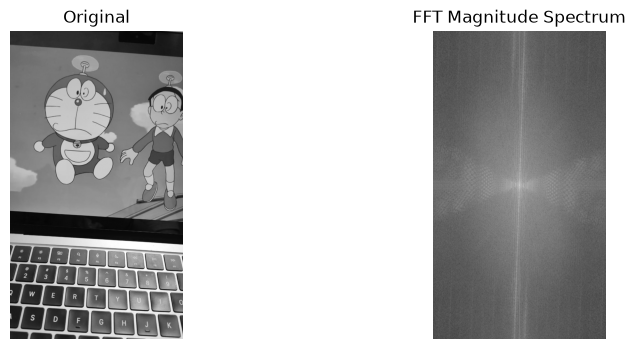

In [13]:
show_fft("../dataset/real/image_2.jpeg")
show_fft("../dataset/screen/image_2.jpeg")

## FFT Example: Image Pair 3

Visualize additional samples to verify that the extracted frequency characteristics remain consistent across different images.

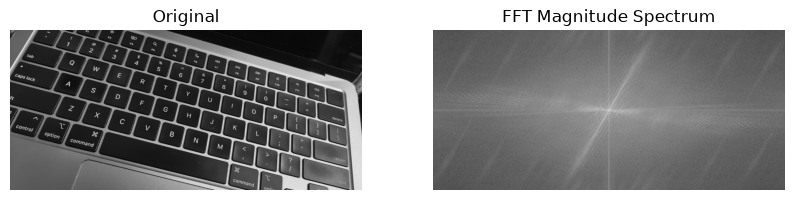

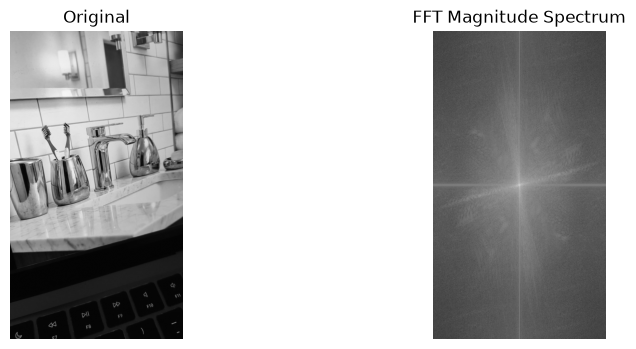

In [15]:
show_fft("../dataset/real/image_3.jpeg")
show_fft("../dataset/screen/image_3.jpeg")

## Extract FFT Features

Define a function that computes numerical FFT-based descriptors for every image.

These descriptors summarize the frequency information and are later used as machine learning features.

In [16]:
def extract_fft_features(image_path):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Resize so every FFT is comparable
    img = cv2.resize(img, (256, 256))

    # FFT
    fft = np.fft.fft2(img)
    fft_shift = np.fft.fftshift(fft)

    magnitude = np.log(np.abs(fft_shift) + 1)

    h, w = magnitude.shape
    cy, cx = h // 2, w // 2

    # ---------- Overall statistics ----------

    fft_mean = np.mean(magnitude)
    fft_std = np.std(magnitude)

    # ---------- Low-frequency energy ----------

    center = magnitude[cy-20:cy+20, cx-20:cx+20]
    low_energy = np.mean(center)

    # ---------- High-frequency energy ----------

    mask = np.ones_like(magnitude, dtype=bool)
    mask[cy-20:cy+20, cx-20:cx+20] = False

    high_energy = np.mean(magnitude[mask])

    # Ratio
    hf_ratio = high_energy / (low_energy + 1e-8)

    # ---------- Horizontal line energy ----------

    horizontal = np.mean(magnitude[cy-2:cy+2, :])

    # ---------- Vertical line energy ----------

    vertical = np.mean(magnitude[:, cx-2:cx+2])

    return {
        "fft_mean": fft_mean,
        "fft_std": fft_std,
        "low_energy": low_energy,
        "high_energy": high_energy,
        "hf_ratio": hf_ratio,
        "horizontal_energy": horizontal,
        "vertical_energy": vertical
    }

## FFT Feature Example

Apply the FFT feature extraction function to a sample image and inspect the generated feature vector.

In [17]:
extract_fft_features("../dataset/real/image_1.jpeg")

{'fft_mean': np.float64(8.620237577331164),
 'fft_std': np.float64(0.728505793052874),
 'low_energy': np.float64(10.028815784242267),
 'high_energy': np.float64(8.584987872453507),
 'hf_ratio': np.float64(0.8560320628665161),
 'horizontal_energy': np.float64(9.402615148783426),
 'vertical_energy': np.float64(9.198880839588362)}

## Generate FFT Feature Dataset

Extract FFT descriptors for every image in the dataset and store them in a structured DataFrame.

In [ ]:
DATASET_PATH = "../dataset"

data = []

for label in ["real", "screen"]:

    folder = os.path.join(DATASET_PATH, label)

    for filename in os.listdir(folder):

        if filename.startswith("."):
            continue

        image_path = os.path.join(folder, filename)

        img = cv2.imread(image_path)

        height, width = img.shape[:2]

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        brightness = np.mean(gray)

        contrast = np.std(gray)

        laplacian = cv2.Laplacian(gray, cv2.CV_64F).var()

        edges = cv2.Canny(gray, 100, 200)

        edge_density = np.sum(edges > 0) / edges.size

        # FFT Features
        fft_features = extract_fft_features(image_path)

        features = {
            "width": width,
            "height": height,
            "brightness": brightness,
            "contrast": contrast,
            "laplacian": laplacian,
            "edge_density": edge_density,

            **fft_features,

            "label": label,
            "filename": filename
        }

        data.append(features)

df = pd.DataFrame(data)

df.head()

,width,height,brightness,contrast,laplacian,edge_density,fft_mean,fft_std,low_energy,high_energy,hf_ratio,horizontal_energy,vertical_energy,label,filename
0,1280,720,86.843356,72.940512,133.974220,0.028845,7.793761,0.988023,10.290016,7.731292,0.751339,9.263871,9.233348,real,image_33.jpeg
1,899,1599,121.585207,53.212329,105.850217,0.020094,7.761115,0.901080,10.001509,7.705049,0.770389,8.725283,9.484126,real,image_25.jpeg
2,1200,1600,115.583521,63.082602,113.837940,0.015818,7.921058,0.871474,9.770370,7.874779,0.805986,9.460184,9.399261,real,image_48.jpeg
3,725,1600,128.303312,53.400933,724.985416,0.142362,8.079321,0.868069,10.258146,8.024796,0.782285,8.921686,9.331769,real,image_6.jpeg
4,720,1600,127.736346,54.394504,1334.930272,0.091699,8.085114,0.886723,10.162933,8.033116,0.790433,9.432658,9.808600,real,image_29.jpeg


## Inspect FFT Features

Display the extracted FFT feature columns to verify that feature extraction was successful.

In [20]:
fft_cols = [
    "fft_mean",
    "fft_std",
    "low_energy",
    "high_energy",
    "hf_ratio",
    "horizontal_energy",
    "vertical_energy"
]

df.groupby("label")[fft_cols].mean()

,fft_mean,fft_std,low_energy,high_energy,hf_ratio,horizontal_energy,vertical_energy
label,,,,,,,
real,7.959327,0.897423,10.101532,7.905718,0.782620,9.075050,9.278754
screen,7.875100,1.023096,10.269204,7.815188,0.760827,9.117017,9.419568


In [21]:
df.to_csv("image_features_fft.csv", index=False)

In [22]:
df.groupby("label")[fft_cols].mean()

,fft_mean,fft_std,low_energy,high_energy,hf_ratio,horizontal_energy,vertical_energy
label,,,,,,,
real,7.959327,0.897423,10.101532,7.905718,0.782620,9.075050,9.278754
screen,7.875100,1.023096,10.269204,7.815188,0.760827,9.117017,9.419568


## Local Binary Pattern (LBP)

Define a function for extracting Local Binary Pattern descriptors.

LBP captures local texture information and is widely used for texture classification tasks.

In [ ]:
from skimage.feature import local_binary_pattern

def extract_lbp_features(image_path):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img, (256,256))

    radius = 3
    n_points = radius * 8

    lbp = local_binary_pattern(
        img,
        n_points,
        radius,
        method="uniform"
    )

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2)
    )

    hist = hist.astype("float")
    hist /= hist.sum()

    return hist

In [25]:
hist = extract_lbp_features("../dataset/real/image_1.jpeg")

print(len(hist))
print(hist)

26
[0.07954407 0.04795837 0.01977539 0.01002502 0.00665283 0.00486755
 0.0042572  0.00386047 0.00396729 0.00382996 0.00427246 0.00579834
 0.00823975 0.00695801 0.00430298 0.00395203 0.00315857 0.00340271
 0.00369263 0.00527954 0.00654602 0.00942993 0.01904297 0.04478455
 0.07875061 0.60765076]


## Color Feature Extraction

Extract color statistics such as mean, standard deviation, and channel-wise information.

Screen recapture images often exhibit different color distributions due to display illumination.

In [26]:
def extract_color_features(image_path):

    img = cv2.imread(image_path)

    img = cv2.resize(img, (256,256))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    rgb_mean = np.mean(img, axis=(0,1))
    rgb_std = np.std(img, axis=(0,1))

    hsv_mean = np.mean(hsv, axis=(0,1))
    hsv_std = np.std(hsv, axis=(0,1))

    return {

        "r_mean": rgb_mean[2],
        "g_mean": rgb_mean[1],
        "b_mean": rgb_mean[0],

        "r_std": rgb_std[2],
        "g_std": rgb_std[1],
        "b_std": rgb_std[0],

        "h_mean": hsv_mean[0],
        "s_mean": hsv_mean[1],
        "v_mean": hsv_mean[2],

        "h_std": hsv_std[0],
        "s_std": hsv_std[1],
        "v_std": hsv_std[2],
    }

In [30]:
color_features = extract_color_features(image_path)

print(color_features)

{'r_mean': np.float64(110.77677917480469), 'g_mean': np.float64(91.48025512695312), 'b_mean': np.float64(80.424560546875), 'r_std': np.float64(76.96735309280525), 'g_std': np.float64(67.37777273392048), 'b_std': np.float64(68.63271812601826), 'h_mean': np.float64(62.386260986328125), 's_mean': np.float64(83.48048400878906), 'v_mean': np.float64(113.2220458984375), 'h_std': np.float64(58.90162036646651), 's_std': np.float64(67.81597402524753), 'v_std': np.float64(76.1994902653728)}


## Histogram of Oriented Gradients (HOG)

Define a function for extracting HOG descriptors.

HOG captures edge orientation information that can reveal structural differences between genuine photographs and screen recapture images.

In [27]:
from skimage.feature import hog

def extract_hog_features(image_path):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    img = cv2.resize(img,(128,128))

    features = hog(

        img,

        orientations=9,

        pixels_per_cell=(8,8),

        cells_per_block=(2,2),

        feature_vector=True

    )

    return {

        "hog_mean": np.mean(features),

        "hog_std": np.std(features),

        "hog_max": np.max(features),

        "hog_min": np.min(features)

    }

In [31]:
hog_features = extract_hog_features(image_path)

print(hog_features)

{'hog_mean': np.float64(0.1092781714977628), 'hog_std': np.float64(0.12584140416279033), 'hog_max': np.float64(0.6915642205455388), 'hog_min': np.float64(0.0)}


## Reflection Feature Extraction

Estimate reflection intensity present within an image.

Display reflections are frequently observed in photographs captured from electronic screens.

In [28]:
def extract_reflection_score(image_path):

    img = cv2.imread(image_path)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    value = hsv[:,:,2]

    bright_pixels = np.sum(value > 240)

    score = bright_pixels / value.size

    return {

        "reflection_score": score

    }

In [32]:
reflection = extract_reflection_score(image_path)

print(reflection)

{'reflection_score': np.float64(0.008418103448275862)}


## Moiré Pattern Detection

Define a feature for estimating moiré artifacts.

Moiré patterns are one of the most distinctive characteristics of screen recapture images.

In [29]:
def extract_moire_score(image_path):

    gray = cv2.imread(image_path,0)

    gray = cv2.resize(gray,(256,256))

    lap = cv2.Laplacian(gray,cv2.CV_64F)

    score = np.var(lap)

    return {

        "moire_score": score

    }

In [33]:
moire = extract_moire_score(image_path)

print(moire)

{'moire_score': np.float64(768.4299509786069)}


## Generate Final Feature Dataset

Combine all extracted descriptors into a single feature table containing every engineered feature for every image.

In [ ]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

records = []

for folder, label in [
    (REAL_DIR, "real"),
    (SCREEN_DIR, "screen")
]:

    for filename in os.listdir(folder):

        if not filename.lower().endswith(IMAGE_EXTENSIONS):
            continue

        image_path = os.path.join(folder, filename)

        img = cv2.imread(image_path)

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        h, w = gray.shape

        brightness = np.mean(gray)

        contrast = np.std(gray)

        laplacian = cv2.Laplacian(gray, cv2.CV_64F).var()

        edges = cv2.Canny(gray,100,200)

        edge_density = np.sum(edges>0)/(h*w)


        fft_features = extract_fft_features(image_path)

        color_features = extract_color_features(image_path)


        hog_features = extract_hog_features(image_path)

        reflection = extract_reflection_score(image_path)

        moire = extract_moire_score(image_path)

        lbp = extract_lbp_features(image_path)

        lbp_dict = {
            f"lbp_{i}": value
            for i, value in enumerate(lbp)
        }

        record = {

            "width": w,
            "height": h,

            "brightness": brightness,
            "contrast": contrast,

            "laplacian": laplacian,

            "edge_density": edge_density,

            **fft_features,

            **color_features,

            **hog_features,

            **reflection,

            **moire,

            **lbp_dict,

            "label": label,

            "filename": filename

        }

        records.append(record)

df = pd.DataFrame(records)

In [35]:
df.head()

,width,height,brightness,contrast,laplacian,edge_density,fft_mean,fft_std,low_energy,high_energy,...,lbp_18,lbp_19,lbp_20,lbp_21,lbp_22,lbp_23,lbp_24,lbp_25,label,filename
0,1280,720,86.843356,72.940512,133.974220,0.028845,7.793761,0.988023,10.290016,7.731292,...,0.012680,0.013504,0.013290,0.016449,0.023026,0.024994,0.077499,0.361893,real,image_33.jpeg
1,899,1599,121.585207,53.212329,105.850217,0.020094,7.761115,0.901080,10.001509,7.705049,...,0.016220,0.016220,0.016983,0.019333,0.022308,0.020813,0.064056,0.348816,real,image_25.jpeg
2,1200,1600,115.583521,63.082602,113.837940,0.015818,7.921058,0.871474,9.770370,7.874779,...,0.010101,0.010086,0.009521,0.011887,0.017670,0.026886,0.045639,0.438065,real,image_48.jpeg
3,725,1600,128.303312,53.400933,724.985416,0.142362,8.079321,0.868069,10.258146,8.024796,...,0.006439,0.006744,0.006927,0.009613,0.014587,0.033936,0.057968,0.493637,real,image_6.jpeg
4,720,1600,127.736346,54.394504,1334.930272,0.091699,8.085114,0.886723,10.162933,8.033116,...,0.009964,0.010635,0.010254,0.015076,0.019928,0.036377,0.090851,0.478714,real,image_29.jpeg


In [37]:
print(df.shape)

(102, 59)


In [38]:
print(df.columns.tolist())

['width', 'height', 'brightness', 'contrast', 'laplacian', 'edge_density', 'fft_mean', 'fft_std', 'low_energy', 'high_energy', 'hf_ratio', 'horizontal_energy', 'vertical_energy', 'r_mean', 'g_mean', 'b_mean', 'r_std', 'g_std', 'b_std', 'h_mean', 's_mean', 'v_mean', 'h_std', 's_std', 'v_std', 'hog_mean', 'hog_std', 'hog_max', 'hog_min', 'reflection_score', 'moire_score', 'lbp_0', 'lbp_1', 'lbp_2', 'lbp_3', 'lbp_4', 'lbp_5', 'lbp_6', 'lbp_7', 'lbp_8', 'lbp_9', 'lbp_10', 'lbp_11', 'lbp_12', 'lbp_13', 'lbp_14', 'lbp_15', 'lbp_16', 'lbp_17', 'lbp_18', 'lbp_19', 'lbp_20', 'lbp_21', 'lbp_22', 'lbp_23', 'lbp_24', 'lbp_25', 'label', 'filename']


In [39]:
df.to_csv("../engineered_features.csv", index=False)

# Summary

This notebook constructed a comprehensive handcrafted feature representation for every image in the dataset.

### Features extracted

- Fast Fourier Transform (FFT)
- Local Binary Patterns (LBP)
- Histogram of Oriented Gradients (HOG)
- Color Statistics
- Reflection Score
- Moiré Score
- Texture Descriptors

These features were consolidated into a structured dataset and exported as `engineered_features.csv`.

The generated feature set serves as the input for the classical machine learning models developed in the next notebook, where Random Forest and XGBoost classifiers are trained and evaluated.